# __Proposta de Métrica: Alinhamento Defensivo__

"O ataque ganha jogos. A defesa ganha campeonatos." Esta frase circula com frequência no mundo do futebol e enaltece a importância que uma linha defensiva sólida tem no desempenho global de uma equipa. Existem várias formas de defender com sucesso e várias ferramentas à disposição de jogadores e equipas técnicas para interromper os ataques adversários, mas em nenhuma delas o alinhamento da linha defensiva é mais importante do que em equipas que procuram pressionar em zonas subidas do terreno e/ou ativar a armadilha de fora de jogo.

Por cá, uma das equipas mais assentes na ideia de uma linha defensiva bem alinhada tem sido o SC Braga de Carlos Vicens. A equipa apresenta-se paciente e confortável em posse, procurando abrir espaços através de trocas de bola rápidas e variações eficazes. No momento defensivo, procura pressionar logo após a perda e, quando tal não é possível, organizar-se com linhas juntas num bloco médio, limitando o jogo interior do adversário e evitando ao máximo descer até demasiado próximo da sua grande área. Neste momento em concreto, os laterais priorizam o posicionamento interior na mesma linha dos centrais sobre a pressão ao homem, ficando a cargo dos extremos recuar para auxiliar os médios e pressionar mais diretamente os adversários no corredor – é neste contexto que surge a importância de ter uma linha defensiva coesa e que não abra espaço a desmarcações por fora e nas costas.

Mas coloca-se uma grande questão: como medir o alinhamento defensivo da equipa? Neste caderno, vamos propor uma métrica para calcular o alinhamento defensivo e aplicá-la a dados fícticios no contexto do SC Braga para avaliar o seu potencial de uso.

_Nota: O relatório em PDF oferece mais contexto e mais conclusões relativamente a esta proposta._

## __Indíce de Conteúdos__</font> <a class="anchor" id="toc"></a>
[Imports](#imports)<br>
[Criação de dados](#dados)<br>
[Validação dos dados criados](#validacao)<br>
[Medir ângulos](#angulos)<br>
[Visualização e Interpretação da Métrica](#visualizacao)<br>
[Visualizações auxiliares](#aux)<br>

## __Imports__</font> <a class="anchor" id="imports"></a>

In [1]:
#!pip install pandas == 2.2.1
#!pip install numpy == 1.24.4
#!pip install matplotlib == 3.8.0
#!pip install mplsoccer == 1.6.1

#!python --version

In [2]:
import pandas as pd
import numpy as np
#import math
#import itertools
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mplsoccer import Pitch, VerticalPitch

## __Criação de dados__</font> <a class="anchor" id="dados"></a>


Na ausência de dados reais, iremos recorrer a dados sintéticos criados tendo como referência os limites das coordenadas utilizadas pela StatsBomb:
* x: 0-120
* y: 0-80

In [3]:
posicao_base = {
    "LB":  {"x": 27, "y": 20},
    "LCB": {"x": 25, "y": 35},
    "RCB": {"x": 25, "y": 45},
    "RB":  {"x": 27, "y": 60}
}

A partir das posições-base acima definidas, iremos criar um dataset com dados recolhidos de 10 sessões de treino em que este alinhamento defensivo foi treinado, e dados de 5 jogos. Aqui, teremos de fazer alguns pressupostos:
* Assumiremos que a variabilidade (ou seja, o potencial para falta de alinhamento) é maior num cenário de jogo do que em treino, em que todo o ambiente é mais controlado e orientado para este aspeto.
* Neste exemplo simplificado, vamos também ignorar a ausência de evolução ao longo do tempo - num contexto real, o desejável (e esperado) seria que com o evoluir dos treinos e jogos o alinhamento defensivo fosse aumentando.
* Por último, vamos ignorar questões relativas à dimensão do relvado e considerar que o treino é feito nas mesmas dimensões que o jogo. Este pressuposto não terá grande impacto no resultado final, mas deve ser algo também levado em consideração sabendo que, à partida, o alinhamento é mais fácil num espaço reduzido do que em dimensões mais alargadas.

In [4]:
def gerar_linha_defensiva(n_sessoes: int,
                          tipo: str,
                          random_state: int) -> pd.DataFrame:
    """
    Gera dados sintéticos para a posição média de uma linha defensiva (futebol).
    Parâmetros:
    - n_sessoes: Número de sessões de treino ou jogos a serem simulados.
    - tipo: Tipo de dados a serem gerados ("treino" ou "jogo").
    - random_state: Para garantir que os dados gerados possam ser replicados.

    Devolve:
    - pd.DataFrame: DataFrame com as colunas "id_treino" ou "id_jogo", "jogador", "x", "y".
    """
    # Adicionar random state para assegurar replicabilidade dos dados
    rng = np.random.default_rng(random_state)
    # Validar valores do parâmetro "tipo"
    if tipo not in ("treino", "jogo"):
        raise ValueError("O parâmetro tipo deverá ser 'treino' ou 'jogo'")

    defenders = list(posicao_base.keys())
    rows = []

    for i in range(1, n_sessoes + 1):
        for d in defenders:
            base_x = posicao_base[d]["x"]
            base_y = posicao_base[d]["y"]
            
            if tipo == "treino":
                noise = rng.uniform(-2, 2, size = 2)   # ruído menor para treinos
            else:
                noise = rng.uniform(-5, 5, size = 2)   # ruído maior para jogos
            
            rows.append({
                f"id_{tipo}": i,
                "jogador": d,
                "x": base_x + noise[0],
                "y": base_y + noise[1]
            })
    
    return pd.DataFrame(rows)

In [5]:
df_treino = gerar_linha_defensiva(n_sessoes = 10, tipo = "treino", random_state = 92)
df_jogo = gerar_linha_defensiva(n_sessoes = 5, tipo = "jogo", random_state = 92)

## __Validação dos dados criados__</font> <a class="anchor" id="validacao"></a>

Vamos recorrer a uma função para elaborar um gráfico que nos permita visualizar os dados que acabámos de criar. Iremos utilizá-la separadamente para treinos e jogos.

In [6]:
def grafico_horizontal_linha_defensiva(df: pd.DataFrame,
                                       id_sessao: int,
                                       tipo: str) -> None:
    """
    Gera um gráfico da linha defensiva com base nos dados fornecidos.
    Parâmetros:
    - df: DataFrame contendo os dados da linha defensiva.
    - tipo: Tipo de dados ("treino" ou "jogo").
    """
    id_col = "id_jogo" if tipo == "jogo" else "id_treino"
    
    pitch = Pitch(pitch_type = "statsbomb", pitch_color = "grass", line_color = "white", stripe = True)
    fig, ax = pitch.draw()

    rect = patches.Rectangle((18, 0), 60 - 18, 80, linewidth = 0, facecolor = "yellow", alpha = 0.3)
    ax.add_patch(rect)

    # Selecionar uma sessão para visualização (exemplo)
    sessao = df[df[id_col] == id_sessao]
    ax.scatter(sessao["x"], sessao["y"], c = "red", s = 150, label = "Defesas", edgecolors = "black")

    # Ligar a posição média dos defesas com linhas
    ax.plot(sessao["x"], sessao["y"], c = "white", linestyle = "--", linewidth = 0.8)

    for i, row in sessao.iterrows():
        ax.text(row["x"] + 3, row["y"] + 1, row["jogador"], color = "white", fontsize = 10, weight = "bold")

    #plt.gca().invert_yaxis()
    plt.show()

#### Treino

Vamos visualizar o primeiro treino, para avaliar se a posição média da linha defensiva faz sentido. Iremos incluir também a zona de abrangência da métrica, de modo a deixar evidente em que contexto estamos a analisar este posicionamento sem posse de bola.

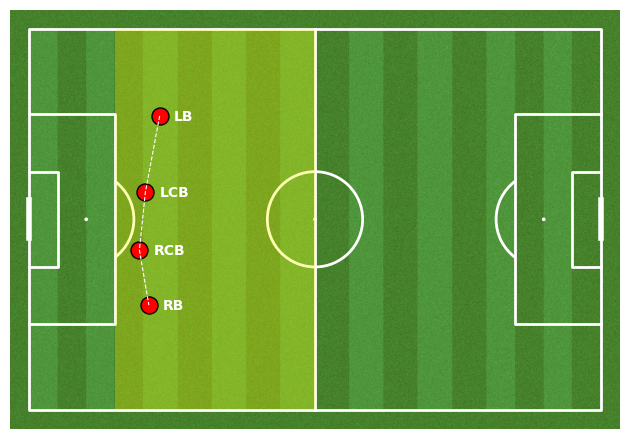

In [7]:
grafico_horizontal_linha_defensiva(df_treino, id_sessao = 1, tipo = "treino")

#### Jogo

Faremos o mesmo para os jogos, selecionando o primeiro como exemplo para visualização.

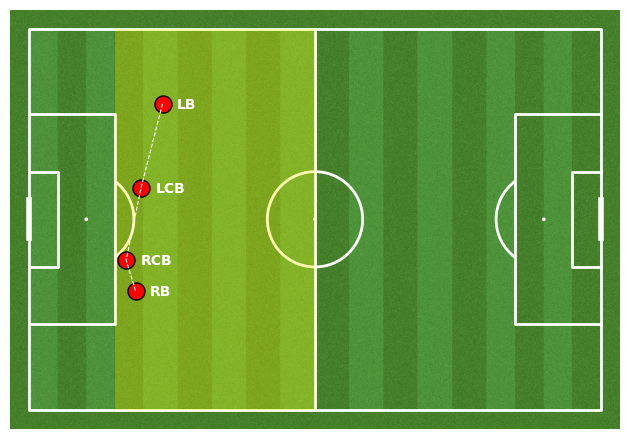

In [8]:
grafico_horizontal_linha_defensiva(df_jogo, id_sessao = 1, tipo = "jogo")

## __Medir ângulos__</font> <a class="anchor" id="angulos"></a>

Tendo visualmente validado os dados criados, podemos passar agora ao cálculo da métrica, conforme descrito abaixo.

Antes de apresentar o método de cálculo da métrica em si, importa compreender em que contexto faz sentido analisá-la. Como abordado anteriormente, o SC Braga procura juntar e alinhar a sua linha defensiva quando o adversário ultrapassa a sua primeira zona de pressão, efetuada para a frente da linha do meio-campo. Aí, a equipa monta um bloco médio e relativamente subido, forçando o jogo exterior e reduzindo o espaço de ação para os opositores. Desta forma, iremos considerar o posicionamento dos defesas do SC Braga sem posse de bola, quando esta se encontra na zona entre a sua grande área e a linha de meio-campo. Neste caso concreto, os dados foram gerados já tendo em consideração este aspeto - num contexto real, os eventos e dados de tracking teriam de ser filtrados para incluir apenas as posições dos jogadores nos momentos relevantes.

Definida a zona de abrangência da métrica, o primeiro passo será __determinar a posição média de cada jogador da linha defensiva__. Com base nestes pontos, é possível __determinar a linha defensiva "ideal"__, que mais não é do que a linha paralela à linha de fundo que minimiza a distância dos defesas até esse posicionamento ótimo. Na perspetiva desta métrica, esta seria a linha sobre a qual estes jogadores se deveriam situar, visto ser aquela que requer uma menor movimentação (considerando os defesas como um todo) face ao seu posicionamento real. De forma mais técnica, podemos entender a linha calculada como a regressão linear regulada para ser paralela à linha de fundo, e que consiste na altura média no campo dos jogadores em análise.

A partir daqui, podemos obter uma métrica individual __calculando a distância, em metros, de cada jogador até à linha "ideal"__ (quanto maior a distância, maior o desposicionamento), mas podemos também __agregar estas distâncias__ de modo a obter métricas coletivas mais completas. Em particular, podemos medir o desposicionamento médio dos jogadores da linha defensiva, o seu valor mínimo, máximo, e até a sua variabilidade com recurso ao desvio-padrão.


In [9]:
def alinhamento_defensivo(df_sessao: pd.DataFrame,
                          linha_defensiva: list,
                          id_col: str,
                          tipo: str) -> dict:
    """
    Calcula a linha "ideal", paralela à linha de fundo, que minimiza a distância dos jogadores da linha defensiva a essa linha.

    Parâmetros:
    - df_sessao: DataFrame com as colunas "jogador", "x", "y" para uma sessão específica.
    - linha_defensiva: Lista com os nomes dos jogadores na linha defensiva (ex: ["LB", "LCB", "RCB", "RB"]).
    - id_col: Nome da coluna que identifica a sessão ("id_jogo" ou "id_treino").
    - tipo: "jogo" ou "treino" para título do gráfico.

    Devolve:
    - dict: Dicionário com as métricas de alinhamento defensivo (média, desvio-padrão, mínimo, máximo dos ângulos).
    """
    # Calcular a linha "ideal", que será a média das posições x dos jogadores da linha defensiva
    jogadores = df_sessao[df_sessao["jogador"].isin(linha_defensiva)]
    xs = jogadores["x"].values
    linha_ideal = xs.mean()
    # Calcular distâncias à linha "ideal"
    distancias = np.abs(xs - linha_ideal)

    # Desenhar campo
    pitch = Pitch(pitch_type = "statsbomb", line_color = "white", pitch_color = "grass", stripe = False, stripe_color = "#198754")
    fig, ax = pitch.draw()

    ax.plot([linha_ideal, linha_ideal], [0, 80], linestyle = "--", color = "yellow", linewidth = 2, alpha = 0.8)

    for jogador in linha_defensiva:
        row = jogadores[jogadores["jogador"] == jogador].iloc[0]
        dx = row.x - linha_ideal
        ax.scatter(row.x, row.y, s = 150, color = "red", edgecolor = "black", zorder = 10, marker = "s")

        ax.text(row.x - 6, row.y + 2, jogador, color = "black", weight = "bold", ha = "center", va = "bottom", fontsize = 12)
        cor = "#074729" if abs(dx) <= 1 else "#6D0505"
        ax.text(row.x + 10, row.y + 2, f"{dx:+.1f} m", color = cor, weight = "bold", ha = "center", va = "bottom", fontsize = 12)
    
    id_sessao = df_sessao[id_col].iloc[0]
    plt.title(f"Visualização do alinhamento defensivo — {tipo} {id_sessao}", color = "black", fontsize = 16, pad = 10)
    plt.show()
        
    # Agregar
    return {
        "distancia_media": np.mean(distancias),
        "distancia_desvio_padrao": np.std(distancias),
        "distancia_minima": np.min(distancias),
        "distancia_maxima": np.max(distancias)
    }

In [10]:
def alinhamento_defensivo_ultimas_sessoes(df: pd.DataFrame,
                                          linha_defensiva: list,
                                          tipo: str = "jogo",
                                          ultimas_sessoes = "tudo") -> pd.DataFrame:
    """
    Calcula métricas de alinhamento defensivo para uma sessão (treino ou jogo).
    Dentro de cada sessão, para cada par de jogadores:
    1. Selecionar o jogador mais atrás no terreno (podia ser também o que está mais adiantado, é apenas por uma questão de consistência).
    2. Conceber uma linha horizontal (imaginária) paralela à linha de fundo e que passe pelo jogador escolhido.
    3. Calcular o ângulo formado pela linha horizontal e o segmento que une os dois jogadores.
    4. Agregar os dados recorrendo à média (alternativamente, ou como complemento, pode ser calculado o mínimo, máximo, e o desvio-padrão).

    Parâmetros:
    - df: DataFrame completo (treino ou jogo) com colunas.
    - linha_defensiva: Lista com os nomes dos jogadores na linha defensiva (ex: ["LB", "LCB", "RCB", "RB"]).
    - tipo: "jogo" ou "treino" para selecionar a coluna de ID relevante.
    - ultimas_sessoes: Número de sessões mais recentes a considerar. Se "tudo", considera todas.

    Devolve:
    - pd.DataFrame: DataFrame com as métricas para cada sessão.
    """
    id_col = "id_jogo" if tipo == "jogo" else "id_treino"
    sessoes = df[id_col].unique()
    
    # Selecionar sessões (treinos/jogos) mais recentes
    sessoes = np.sort(sessoes)
    if ultimas_sessoes != "tudo":
        sessoes = sessoes[-ultimas_sessoes:]
    
    resultados = []
    for sessao in sessoes:
        df_sessao = df[df[id_col] == sessao]
        metricas = alinhamento_defensivo(df_sessao, linha_defensiva, id_col, tipo)
        metricas[id_col] = sessao
        resultados.append(metricas)
    
    return pd.DataFrame(resultados).set_index(id_col)

### __Visualização e interpretação da métrica__</font> <a class="anchor" id="visualizacao"></a>

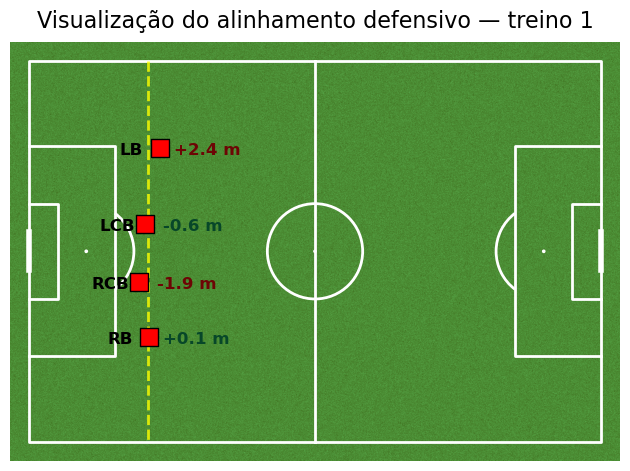

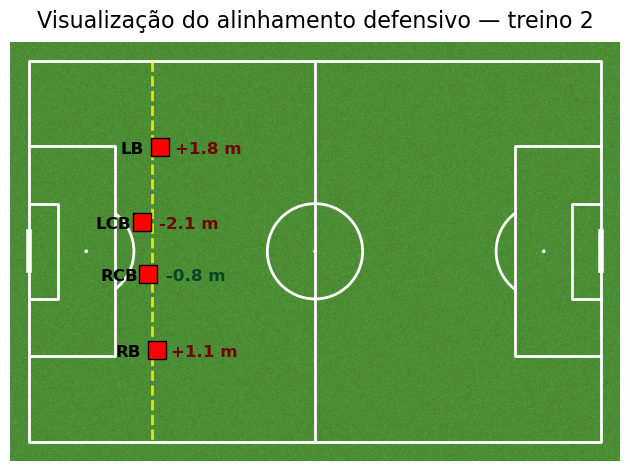

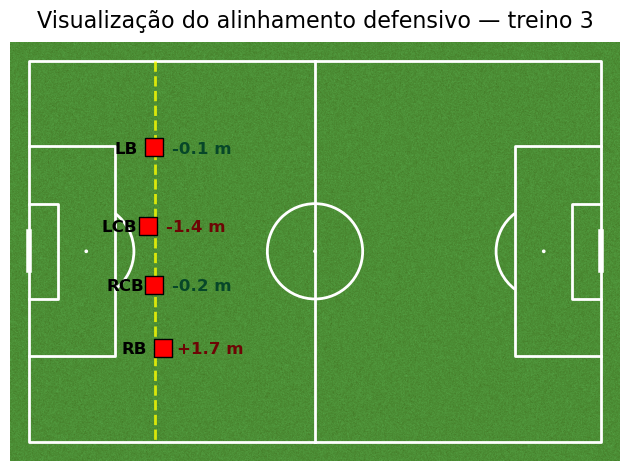

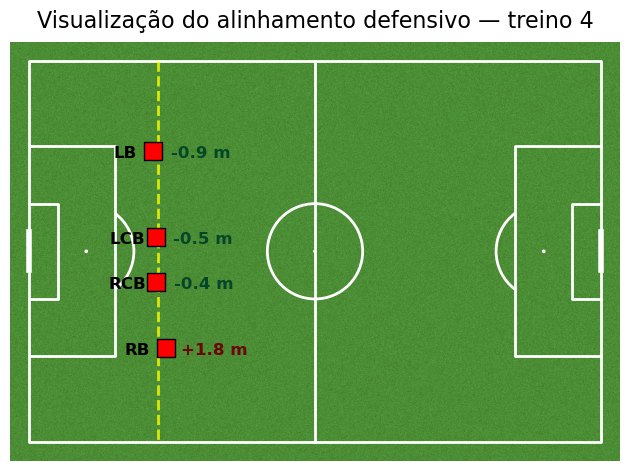

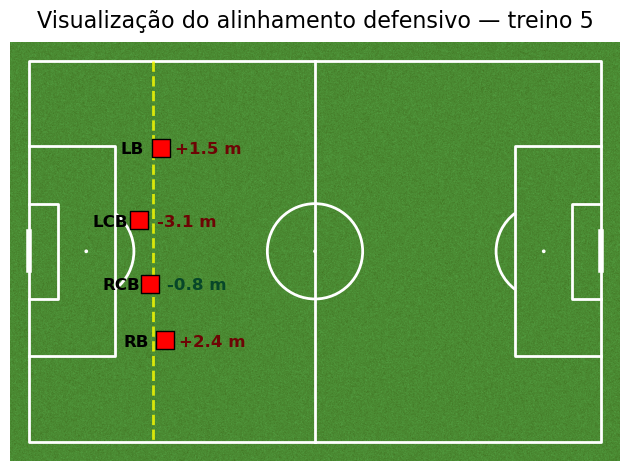

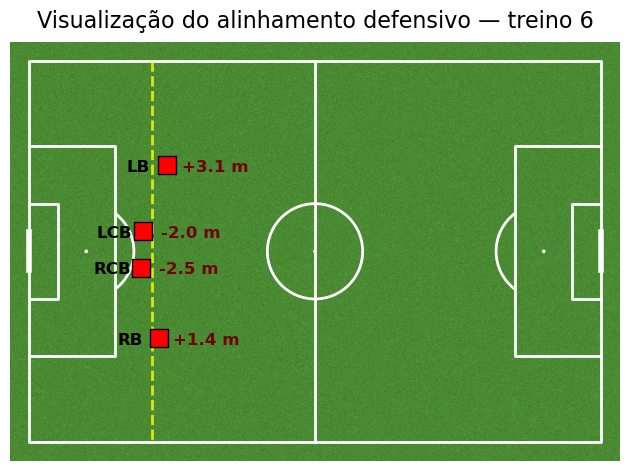

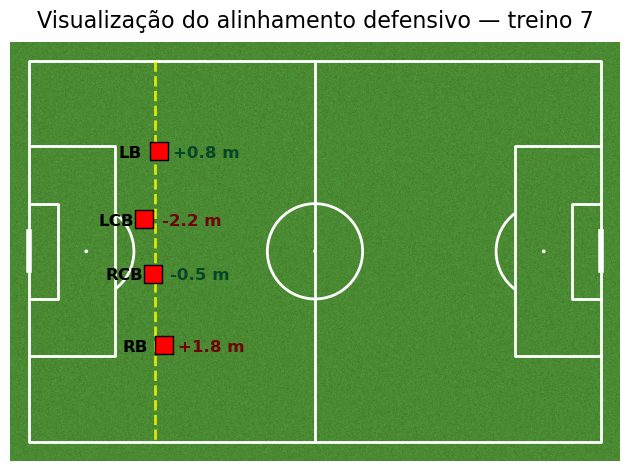

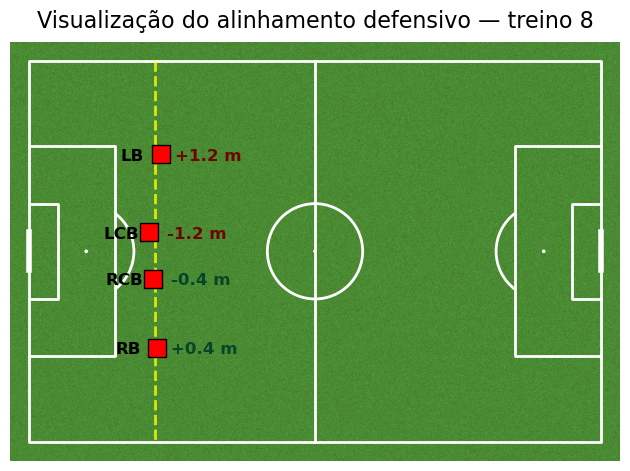

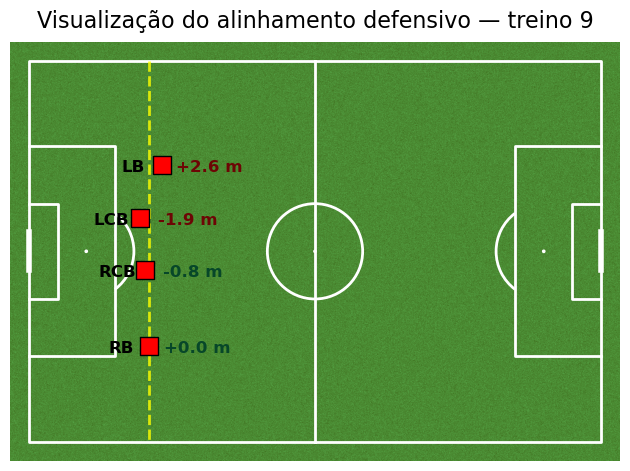

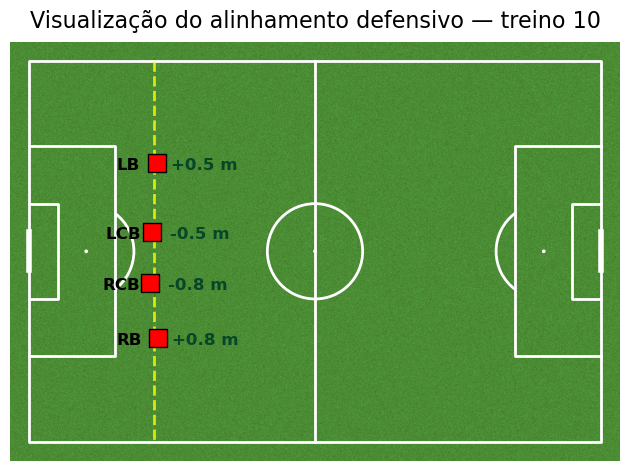

,distancia_media,distancia_desvio_padrao,distancia_minima,distancia_maxima
id_treino,,,,
1,1.247572,0.914062,0.115856,2.379289
2,1.448665,0.547802,0.759291,2.138039
3,0.860755,0.710129,0.112072,1.721511
4,0.898796,0.554347,0.428592,1.797593
5,1.939270,0.858388,0.801846,3.076694
6,2.238092,0.619657,1.393811,3.082374
7,1.329867,0.699603,0.479606,2.180128
8,0.798624,0.392931,0.403756,1.193492
9,1.342928,1.002715,0.044660,2.641196


In [11]:
linha_defensiva = ["LB", "LCB", "RCB", "RB"]
alinhamento_defensivo_ultimas_sessoes(df_treino, linha_defensiva, tipo = "treino", ultimas_sessoes = "tudo")

As visualizações e a tabela identificam os treinos 8 e 10 como aqueles em que a linha defensiva aparece, em média, mais próxima do seu posicionamento "ideal". Os treinos 3 e 4 também apresentam bons números - no treino 4, inclusive, os dois centrais estiveram quase sempre perfeitamente alinhados. <br>
Podemos concluir que o treino 10 foi mesmo aquele em que os defesas se apresentaram mais alinhados. Além de ser aquele com menor distância média para a linha "ideal", é também aquele com menor variabilidade - isto é, em que nenhum jogador se destaca por estar mais próximo ou distante do que os colegas -, o que se deve em grande parte ao facto de ser o treino com menor distância máxima para a linha ideal (<0.85m). A visualização também complementa estas conclusões, sendo este o único treino em que as distâncias aparecem todas a verde.

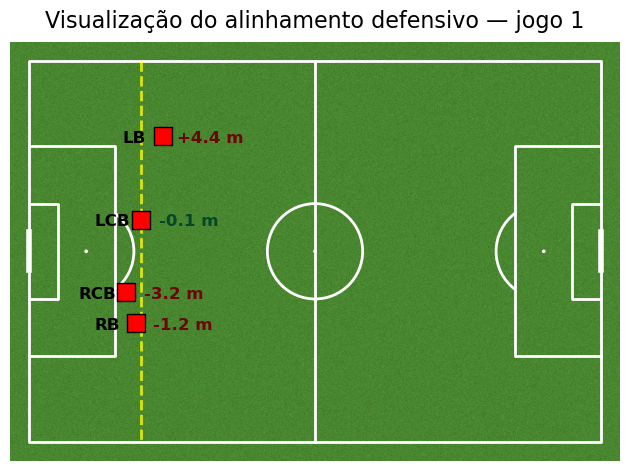

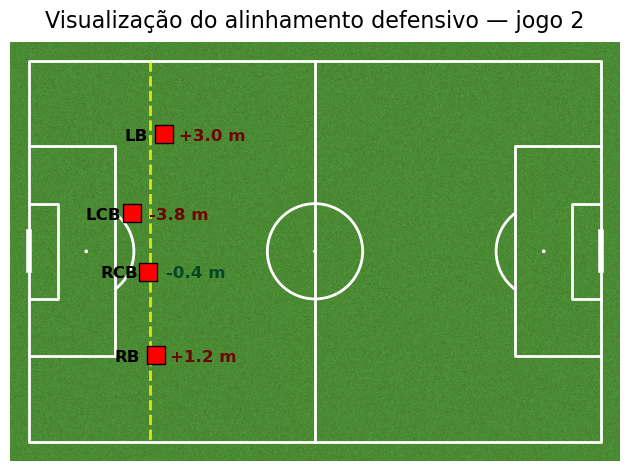

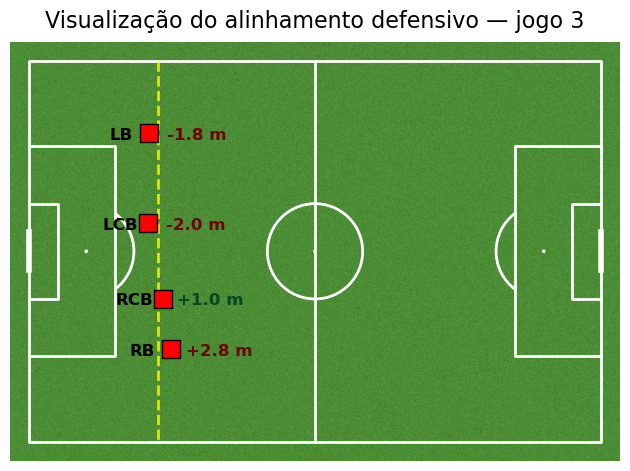

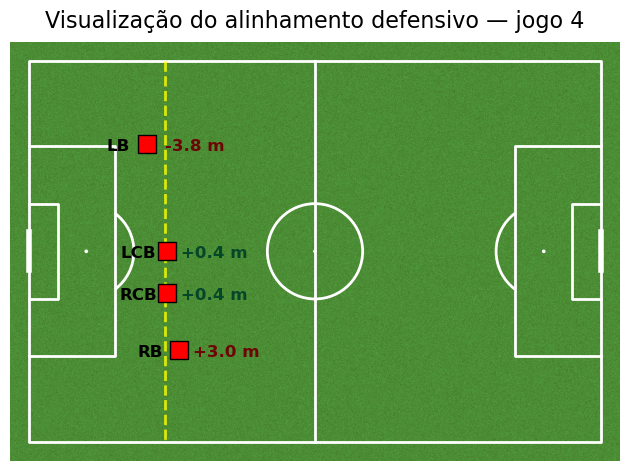

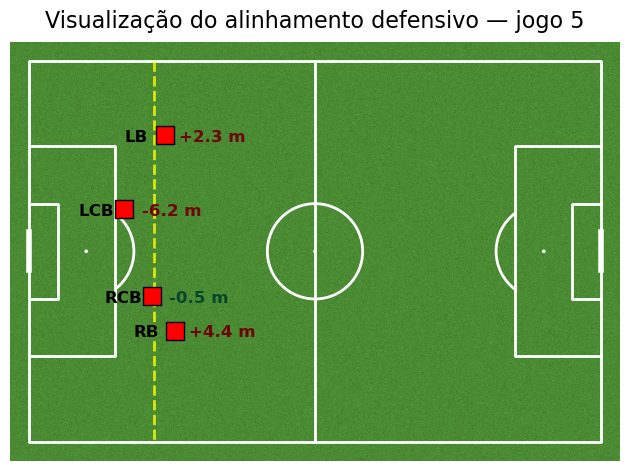

,distancia_media,distancia_desvio_padrao,distancia_minima,distancia_maxima
id_jogo,,,,
1,2.224111,1.701821,0.057212,4.448223
2,2.121662,1.369506,0.398228,3.845097
3,1.890460,0.650503,0.977144,2.803777
4,1.896675,1.523572,0.370847,3.793349
5,3.348175,2.145970,0.504615,6.191736


In [12]:
linha_defensiva = ["LB", "LCB", "RCB", "RB"]
alinhamento_defensivo_ultimas_sessoes(df_jogo, linha_defensiva, tipo = "jogo", ultimas_sessoes = "tudo")

Como seria expectável, em jogo será sempre mais complicado atingir o alinhamento "perfeito" comparativamente ao treino. Aqueles em que a equipa apresentou melhor desempenho neste indicador foram os jogos 3 e 4, com menor distância média para a linha "ideal". Dentro destes, o jogo 4 destaca-se por uma maior variabilidade (o que não é desejável), muito graças aos dois laterais, fortemente desajustados face aos dois centrais, que até apresentam um posicionamento bastante bom.

Em sentido contrário, o jogo 5 evidencia um grande desposicionamento de todos os defesas, sendo visualmente notória a ausência de coordenação no alinhamento defensivo, além de apresentar piores indicadores quando comparado com as restantes partidas.

Importa salientar que, naturalmente, esta métrica não seria apresentada à equipa técnica neste formato de tabela, visto que se tornaria moroso de analisar e poderia perder a mensagem que se pretende transmitir. A solução passaria, por exemplo, por acrescentar informação sucinta a um dashboard de modo a potenciar conclusões imediatas e mais acionáveis.

### __Visualizações auxiliares__</font> <a class="anchor" id="aux"></a>

Neste capítulo incluíremos apenas algumas visualizações para complementar o relatório e apresentação, começando por um exemplo da estrutura-tipo do SC Braga (equipa em análise neste caso de estudo, a vermelho) a defender em bloco médio. Quando a bola cai num dos corredores, a equipa movimenta-se em bloco para criar superioridade defensiva nesse lado.

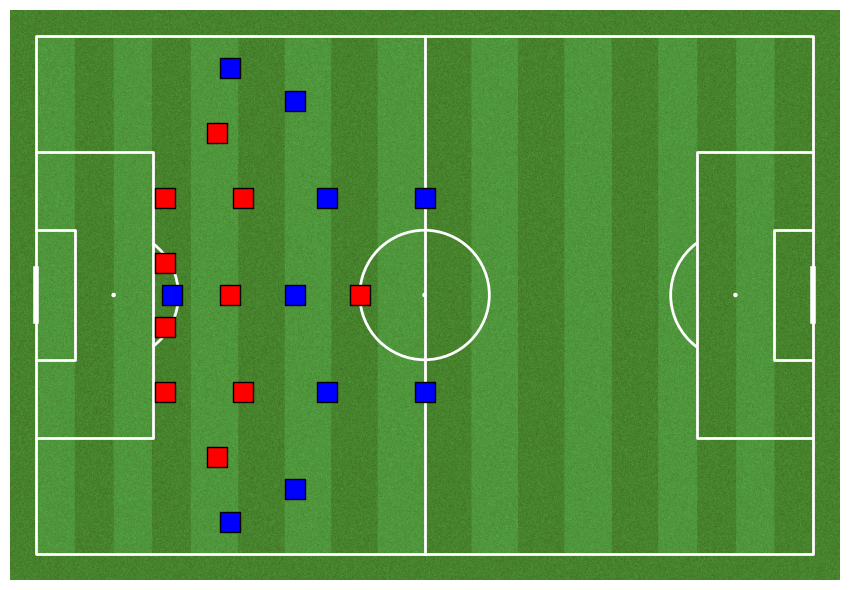

In [13]:
# Create pitch
pitch = Pitch(pitch_type = "statsbomb", pitch_color = "grass", line_color = "white", stripe = True, stripe_color = "#198754")
fig, ax = pitch.draw(figsize = (10, 6))

# Vermelhos
red_def = [(20, 55), (20, 45), (20, 35), (20, 25)]
red_mid = [(32, 55), (30, 40), (32, 25)]
red_am = [(28, 65), (28, 15)]
red_st = [(50, 40)]
red_players = red_def + red_mid + red_am + red_st

for x, y in red_players:
    ax.scatter(x, y, s = 200, color = "red", edgecolor = "black", marker = "s", zorder = 5)

# Azuis
blue_def = [(40, 70), (60, 55), (60, 25), (40, 10)]
blue_mid = [(45, 55), (40, 40), (45, 25)]
blue_fw = [(30, 75), (21, 40), (30, 5)]
blue_players = blue_def + blue_mid + blue_fw

for x, y in blue_players:
    ax.scatter(x, y, s = 200, color = "blue", edgecolor = "black", marker = "s", zorder = 5)

plt.show()

Na visualização abaixo, destacamos a área em que a métrica vai ser analisada, no momento da posse de bola do adversário.

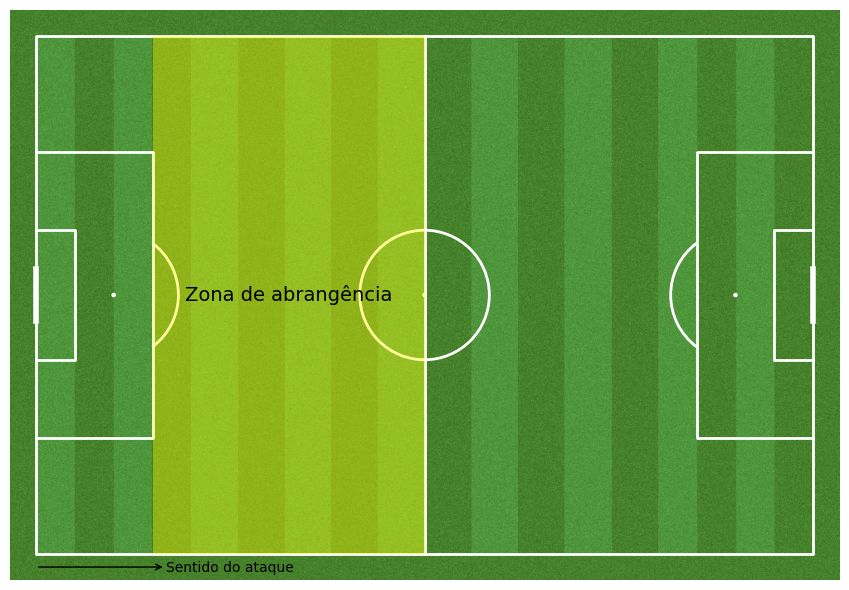

In [14]:
pitch = Pitch(pitch_type = "statsbomb", line_color = "white", pitch_color = "grass", stripe = True)
fig, ax = pitch.draw(figsize = (10, 6))

rect = patches.Rectangle((18, 0), 60 - 18, 80, linewidth = 0, facecolor = "yellow", alpha = 0.4)
ax.add_patch(rect)
ax.text(39, 40, "Zona de abrangência", color = "black", ha = "center", va = "center", fontsize = 14)

ax.annotate("", xy = (20, 82), xytext = (0, 82), arrowprops = dict(arrowstyle = "->", color = "black", lw = 1))
ax.text(30, 82.2, "Sentido do ataque", ha = "center", va = "center", fontsize = 10, color = "black")

plt.show()